<a href="https://colab.research.google.com/github/IDGS-902-23001704/ECBD-IDGS902-23001704/blob/main/No_Supervisados2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# 1. Simulamos datos del sistema IoT
# Variables: [Hora_Entrada, Frecuencia_Semanal, Tiempo_Estancia_Minutos, Confianza_Sensor]
datos_accesos = np.array([
    [8, 10, 600, 0.98], [7, 12, 580, 0.99], [8, 11, 610, 0.95], # Grupo 1: Residentes (Mañanas, mucha estancia)
    [14, 2, 15, 0.60], [13, 3, 20, 0.55], [15, 1, 10, 0.65],    # Grupo 2: Repartidores/Servicios (Tardes, poca estancia)
    [20, 1, 120, 0.85], [19, 2, 180, 0.80], [21, 1, 200, 0.90]  # Grupo 3: Visitas (Noches, estancia media)
])

In [5]:
# 2. Preprocesamiento (Escalar los datos es vital para PCA y K-Means)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos_accesos)

In [7]:
# 3. Reducción de Dimensionalidad (PCA)
# Pasamos de 4 variables a solo 2 componentes principales para poder graficar
pca = PCA(n_components=2)
datos_reducidos = pca.fit_transform(datos_escalados)
print(f"Varianza explicada por PCA: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Varianza explicada por PCA: 99.46%


In [8]:
# 4. Agrupación (K-Means)
# Buscamos 3 grupos de comportamiento
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
etiquetas_clusters = kmeans.fit_predict(datos_reducidos)

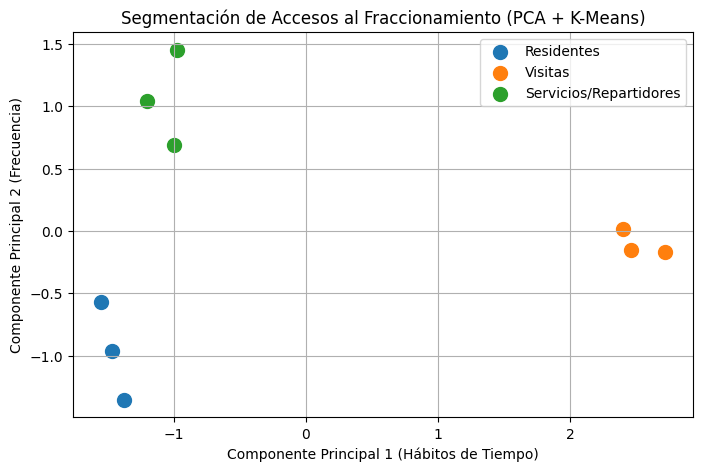


--- ANÁLISIS FINALIZADO ---
El algoritmo separó los perfiles de acceso correctamente sin necesidad de etiquetas previas.


In [9]:
# 5. Visualización (Lo que vería el administrador de seguridad)
plt.figure(figsize=(8, 5))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
nombres_grupos = ['Residentes', 'Visitas', 'Servicios/Repartidores']

for i in range(3):
    puntos = datos_reducidos[etiquetas_clusters == i]
    plt.scatter(puntos[:, 0], puntos[:, 1], s=100, c=colores[i], label=nombres_grupos[i])

plt.title('Segmentación de Accesos al Fraccionamiento (PCA + K-Means)')
plt.xlabel('Componente Principal 1 (Hábitos de Tiempo)')
plt.ylabel('Componente Principal 2 (Frecuencia)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- ANÁLISIS FINALIZADO ---")
print("El algoritmo separó los perfiles de acceso correctamente sin necesidad de etiquetas previas.")